In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision

In [2]:
image_path = "/Users/deven/"

In [5]:
from torchvision import datasets

training_data = datasets.FashionMNIST(root=image_path, train=True, download=True)

100.0%
100.0%
100.0%
100.0%


In [2]:
device = torch.accelerator.current_accelerator().type

In [3]:
x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=np.float32)
tensor = torch.from_numpy(x)

In [4]:
tensor

tensor([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

In [5]:
tensor.type()

'torch.FloatTensor'

In [6]:
b = torch.Tensor(tensor)

In [7]:
b

tensor([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

In [8]:
b.type()

'torch.FloatTensor'

In [9]:
id(b)

4461522576

In [10]:
id(x)

4451003792

In [11]:
(x == b).all()

tensor(True)

In [12]:
type(b)

torch.Tensor

In [13]:
type(x)

numpy.ndarray

In [14]:
type(tensor)

torch.Tensor

In [15]:
tensor = torch.Tensor([[1, 2], [1, 2]])

In [16]:
tensor @ tensor.T

tensor([[5., 5.],
        [5., 5.]])

In [17]:
tensor.matmul(tensor.T)

tensor([[5., 5.],
        [5., 5.]])

In [18]:
tensor * tensor

tensor([[1., 4.],
        [1., 4.]])

In [19]:
tensor * tensor.T

tensor([[1., 2.],
        [2., 4.]])

In [20]:
tensor_t = tensor.T

In [21]:
tensor_t * tensor

tensor([[1., 2.],
        [2., 4.]])

In [22]:
tensor_t @ tensor

tensor([[2., 4.],
        [4., 8.]])

In [36]:
tensor @ tensor_t

tensor([[5., 5.],
        [5., 5.]])

In [37]:
tensor

tensor([[1., 2.],
        [1., 2.]])

In [38]:
tensor.requires_grad = True

In [39]:
tensor

tensor([[1., 2.],
        [1., 2.]], requires_grad=True)

Topic 2: Pytorch Autograd
================

If you flag a torch Tensor with the attribute `x.requires_grad=True`, then pytorch will automatically keep track the computational history of all tensors that are derived from `x`.  This allows pytorch to figure out derivatives of any scalar result with regard to changes in the components of x.

<img src="https://raw.githubusercontent.com/davidbau/how-to-read-pytorch/6ce891301e79aa8e2164a703c08257a52b2d1ad3/notebooks/autograd-graph.png" style="max-width:100%">



**The function `torch.autograd.grad(output_scalar, [list of input_tensors])` computes `d(output_scalar)/d(input_tensor)` for each input tensor component in the list.  For it to work, the input tensors and output must be part of the same `requires_grad=True` compuation.**

In the example, `x` is explicitly marked `requires_grad=True`, so `y.sum()`, which is derived from `x`, automatically comes along with the computation history, and can be differentiated.

In [74]:
x = torch.linspace(0, 5, 100, requires_grad=True)
y = (x**2).cos()
s = y.sum()  # scalar
[dydx] = torch.autograd.grad(
    s, [x]
)  # list of input tensors, and outputs dy/dx of each input tensor

In [76]:
[a] = [dydx]

(Note that in the example above, because the components of the vector space are independent of each other, we happen to have `dy[j] / dx[i] == 0` when `j != i`, so that `d(y.sum())/dx[i] = dy[i]/dx[i]`.  That means computing a single gradient vector of the sum `s` is equiavlent to computing elementwise derivatives `dy/dx`.)

**Detaching tensors from the computation history.**

Every tensor that depends on `x` will be `requires_grad=True` and connected to the complete computation history. But if you were to convert a tensor to a regular python number, pytorch would not be able to see the calculations and would not be able to compute gradients on it.

To avoid programming mistakes where some computation invisibly goes through a non-pytorch number that cannot be tracked, pytorch disables requires-grad tensors from being converted to untrackable numbers.  You need to explicitly call `x.detach()` or `y.detach()` first, to explicitly say that you want an untracked reference, before plotting the data or using it as non-pytorch numbers.

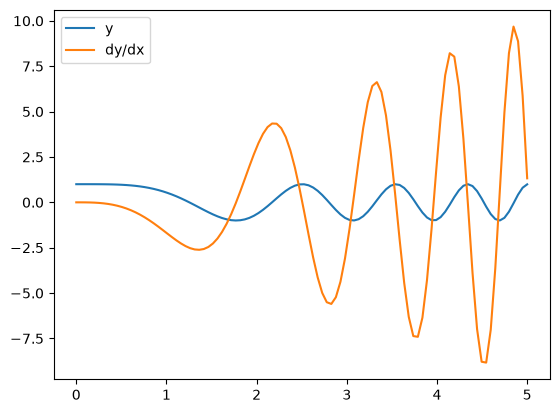

In [78]:
plt.plot(x.detach(), y.detach(), label="y")
plt.plot(x.detach(), dydx, label="dy/dx")
plt.legend()
plt.show()

In [40]:
y = tensor.sum()

In [41]:
y

tensor(6., grad_fn=<SumBackward0>)

In [42]:
y.backward()

In [44]:
gradient = tensor.grad

In [46]:
gradient

tensor([[1., 1.],
        [1., 1.]])

In [71]:
type(a)

torch.Tensor

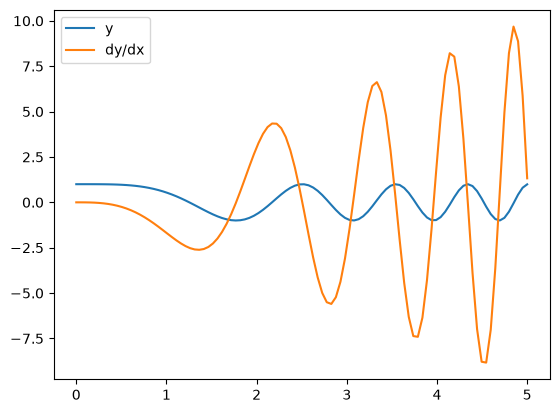

In [73]:
import matplotlib.pyplot as plt

plt.plot(x.detach(), y.detach(), label="y")
plt.plot(x.detach(), a, label="dy/dx")
plt.legend()
plt.show()

## detach
The .detach() method in PyTorch creates a new tensor that shares the same data as the original but is completely removed from the computational graph. This means gradients will not be computed for this tensor during the backward pass, effectively making requires_grad=False

In [50]:
x = torch.arange(1, 100, 1, requires_grad=True, dtype=torch.float)
y = x.cos().sum()

In [51]:
y.backward()
gradient = x.grad

In [52]:
gradient

tensor([-0.8415, -0.9093, -0.1411,  0.7568,  0.9589,  0.2794, -0.6570, -0.9894,
        -0.4121,  0.5440,  1.0000,  0.5366, -0.4202, -0.9906, -0.6503,  0.2879,
         0.9614,  0.7510, -0.1499, -0.9129, -0.8367,  0.0089,  0.8462,  0.9056,
         0.1324, -0.7626, -0.9564, -0.2709,  0.6636,  0.9880,  0.4040, -0.5514,
        -0.9999, -0.5291,  0.4282,  0.9918,  0.6435, -0.2964, -0.9638, -0.7451,
         0.1586,  0.9165,  0.8318, -0.0177, -0.8509, -0.9018, -0.1236,  0.7683,
         0.9538,  0.2624, -0.6702, -0.9866, -0.3959,  0.5588,  0.9998,  0.5216,
        -0.4362, -0.9929, -0.6367,  0.3048,  0.9661,  0.7392, -0.1674, -0.9200,
        -0.8268,  0.0266,  0.8555,  0.8979,  0.1148, -0.7739, -0.9511, -0.2538,
         0.6768,  0.9851,  0.3878, -0.5661, -0.9995, -0.5140,  0.4441,  0.9939,
         0.6299, -0.3132, -0.9684, -0.7332,  0.1761,  0.9235,  0.8218, -0.0354,
        -0.8601, -0.8940, -0.1060,  0.7795,  0.9483,  0.2453, -0.6833, -0.9836,
        -0.3796,  0.5734,  0.9992])

In [54]:
id(x.detach())

6027442080

In [55]:
id(x)

6082494320

Pytorch Neural Network Modules
==============================

Pytorch uses the `torch.nn.Module` class to represent a neural network.

A `Module` is just a **callable** function that can be:

 * **Parameterized** by trainable `Parameter` tensors that the module can list out.
 * **Composed** out of children `Module`s that contribute parameters.
 * **Saved and Loaded** by listing named parameters and other attribute buffers.

Pytorch comes with several built-in elementary network modules, like a generic single-layer `Linear` network, or a generic `Sequential` composition of other networks, but of course you can write your own `Module` subclasses by just defining `Parameter` attributes and using them to implement a computation.

To see how every `Module` manages its own portion of responsibilities of all the network duties above, we first look at how to use the built-in `Linear` and `Sequential` modules.

Using torch.nn.Linear as a Neural Network
=========================================

The linear layer is not just a good starting example: it is the fundmental workhorse of all neural networks, so as simple as it is, it is worth examining carefully.

`torch.nn.Linear` implements the function `y = Ax + b`, which takes m-dimensional input `x` and produces n-dimensional output `y`, by multiplying by the n &times; m matrix `A` (whose specific values are called the `weight`) and adding n-dimensional vector `b` (whose values are called the `bias`).  We can make a Linear network with 3d input and 2d output just like this:

In [56]:
linear = torch.nn.Linear(3, 2)
linear

Linear(in_features=3, out_features=2, bias=True)

In [57]:
x = torch.tensor([1.0, 2.0, 3.0])
linear(x)

tensor([-0.7156, -0.6807], grad_fn=<ViewBackward0>)

In [58]:
print(f" weight: {linear.weight}, bias: {linear.bias}")

 weight: Parameter containing:
tensor([[-0.3202,  0.3913, -0.3090],
        [-0.5321, -0.3086,  0.1542]], requires_grad=True), bias: Parameter containing:
tensor([-0.2510,  0.0059], requires_grad=True)


In [59]:
dir(linear)

['T_destination',
 '__annotations__',
 '__call__',
 '__class__',
 '__constants__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_apply',
 '_backward_hooks',
 '_backward_pre_hooks',
 '_buffers',
 '_call_impl',
 '_compiled_call_impl',
 '_forward_hooks',
 '_forward_hooks_always_called',
 '_forward_hooks_with_kwargs',
 '_forward_pre_hooks',
 '_forward_pre_hooks_with_kwargs',
 '_get_backward_hooks',
 '_get_backward_pre_hooks',
 '_get_name',
 '_is_full_backward_hook',
 '_load_from_state_dict',
 '_load_state_dict_post_hooks',
 '_load_state_dict_pre_hooks',
 '_maybe_warn_non_full_backward_hook',
 '_modules',
 '_named_members',
 '_non_per

In [60]:
for name, parameter in linear.named_parameters():
    print(f"Name:{name}, parameter:{parameter}")

Name:weight, parameter:Parameter containing:
tensor([[-0.3202,  0.3913, -0.3090],
        [-0.5321, -0.3086,  0.1542]], requires_grad=True)
Name:bias, parameter:Parameter containing:
tensor([-0.2510,  0.0059], requires_grad=True)


**A Module can be saved by saving its state_dict.**   `net.state_dict()` is similar to `net.named_parameters()` but it **returns a detached reference to the data (that is, `requires_grad=False`) so the data can be saved directly.**

**Also, for more complicated modules, `state_dict()` may include other non-trainable attributes that are needed to save the network's state.**

In [62]:
for name, parameter in linear.state_dict().items():
    print(f"Name:{name}, parameter:{parameter}")

Name:weight, parameter:tensor([[-0.3202,  0.3913, -0.3090],
        [-0.5321, -0.3086,  0.1542]])
Name:bias, parameter:tensor([-0.2510,  0.0059])


In [63]:
import os

os.makedirs("checkpoints", exist_ok=True)

In [67]:
torch.save(linear.state_dict(), "checkpoints/linear.pth")

**load_state_dict() can be used to reload a saved Module.**

Pytorch also comes with convenient `torch.save` and `torch.load` functions for saving state dicts to files.

In [68]:
linrar_1 = torch.load("checkpoints/linear.pth")

In [69]:
linrar_1

OrderedDict([('weight',
              tensor([[-0.3202,  0.3913, -0.3090],
                      [-0.5321, -0.3086,  0.1542]])),
             ('bias', tensor([-0.2510,  0.0059]))])